## Planteamiento de hipótesis iniciales

El objetivo del análisis es identificar qué características influyen en la probabilidad de que un paciente desarrolle enfermedad coronaria en los próximos 10 años (`TenYearCHD`).

### Hipótesis principales

- La edad (`age`) tendrá una fuerte relación positiva con el riesgo, ya que el riesgo cardiovascular aumenta con la edad.
- La presión arterial (`sysBP`, `diaBP`) será una de las variables más influyentes, debido a su relación directa con enfermedades cardíacas.
- El colesterol (`totChol`) y la glucosa (`glucose`) estarán asociados a mayor riesgo.
- El índice de masa corporal (`BMI`) podría influir, aunque de forma más moderada.
- Variables como `currentSmoker` y `cigsPerDay` tendrán impacto debido al efecto del tabaquismo.
- Variables médicas como `diabetes` o `prevalentHyp` probablemente tengan una fuerte relación con el target.

### Variables con menor impacto esperado

- `education` podría tener una relación indirecta (socioeconómica), pero no directa.
- `heartRate` podría no ser una variable determinante en este contexto.

Asi es como considero que tienen valor las variables en funicon de desarrollar una enfermedad pero es lo que voy a ver con el eda. 

INICIO DEL ANALISIS 

In [36]:
import pandas as pd 
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.stats import skew, kurtosis
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

In [3]:
df = pd.read_csv ("../data/framingham.csv")

In [4]:
df.head ()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## Carga del dataset

En este primer paso, cargo el dataset original sin realizar ningún tipo de modificación sobre los datos.

In [5]:
df.tail ()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,0,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0


Informacion general

In [6]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


Dimensiones 

In [7]:
df.shape 

(4240, 16)

Tipos de variables 

In [8]:
df.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

Estadisticas basicas

In [9]:
df.describe 

<bound method NDFrame.describe of       male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   
4238     1   40        3.0              0         0.0     0.0   
4239     0   39        3.0              1        30.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0      

## Inspección inicial del dataset

A continuación, realizo una primera exploración del dataset con el objetivo de comprender su estructura general.

Utilizo funciones como `info()`, `shape`, `dtypes` y `describe()` para obtener información sobre:

- Número de filas y columnas
- Tipos de variables (numéricas o categóricas)
- Presencia de valores nulos
- Estadísticas básicas como media, desviación estándar, mínimos y máximos

Este paso es fundamental para identificar posibles problemas en los datos y definir la estrategia de análisis posterior.

In [10]:
df.duplicated().sum()

np.int64(0)

### Detección de registros duplicados

En este paso compruebo si existen registros duplicados en el dataset utilizando la función `duplicated()`.

El resultado obtenido es 0, lo que indica que no existen observaciones repetidas en el dataset. Esto es positivo, ya que evita posibles sesgos en el análisis derivados de la duplicación de información.

In [11]:
# Valores nulos por columna
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

he utilizado la ia para sacarlo en porcentaje 

In [12]:
# Porcentaje de nulos
nulls = df.isnull().sum()
nulls_percent = (nulls / len(df)) * 100

nulls_df = pd.DataFrame({
    'nulos': nulls,
    'porcentaje': nulls_percent
})

nulls_df.sort_values(by='porcentaje', ascending=False)

,nulos,porcentaje
glucose,388,9.150943
education,105,2.476415
BPMeds,53,1.250000
totChol,50,1.179245
cigsPerDay,29,0.683962
BMI,19,0.448113
heartRate,1,0.023585
male,0,0.000000
age,0,0.000000
currentSmoker,0,0.000000


## Análisis de valores nulos

Tras analizar los valores nulos del dataset, observo que la mayoría de las variables presentan una cantidad muy baja de datos nulos.

La variable con mayor porcentaje de valores nulos es `glucose`, con aproximadamente un 9.15%, seguida de `education` con un 2.47%. El resto de variables presentan porcentajes inferiores al 2%, lo cual indica que el dataset es relativamente completo.

Dado que ninguna variable presenta un porcentaje excesivamente alto de valores nulos, decido no eliminar ninguna columna en esta fase del análisis.

Por otro lado, aunque será necesario tratar estos valores despues, en este punto del EDA no realizo imputaciones para evitar introducir sesgos o data leakage en el análisis.

Este análisis me permite identificar qué variables requerirán atención en el proceso.

Voy a empezar haciendo el analisis univariable con la Variable `age`

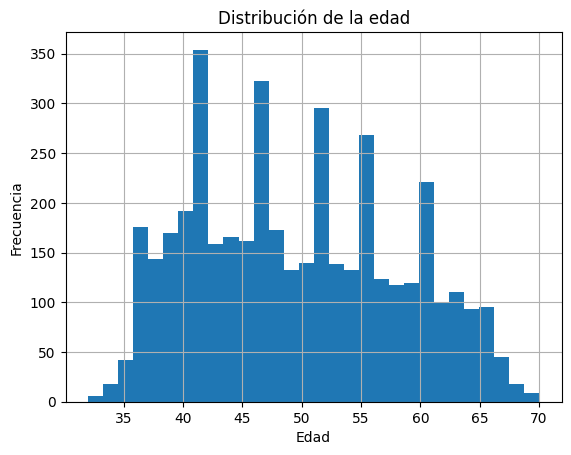

In [13]:
# Histograma
df['age'].hist(bins=30)
plt.title("Distribución de la edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

<Axes: >

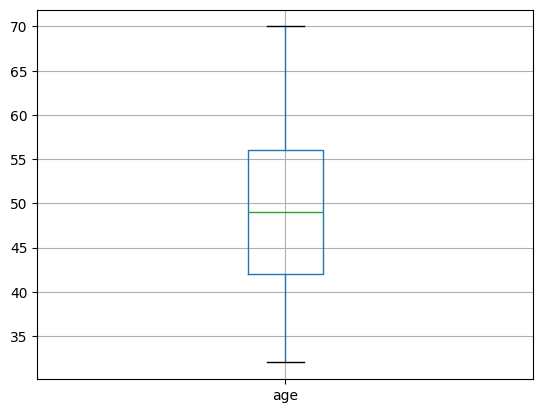

In [14]:
df.boxplot(column='age')

he utilizado la ia para sacar estas variables 

In [15]:
skew(df['age'])

np.float64(0.22878605874310656)

Calcula la asimetría:
cerca de 0 → distribución bastante equilibrada
positivo → cola hacia valores altos
negativo → cola hacia valores bajos

In [16]:
kurtosis(df['age'])

np.float64(-0.990142826228277)

Calcula la curtosis:
alta → más valores extremos / colas más pesadas
baja → distribución más plana

Antes de analizar la variable `age`, voy a utilizar tres herramientas:

1. Un histograma, para ver cómo se distribuyen las edades de los pacientes.
2. Un boxplot, para detectar visualmente posibles valores atípicos.
3. Skewness y kurtosis, para medir la forma de la distribución de manera numérica.

Esto me permite entender la variable antes de relacionarla con otras variables o con el target.

### Análisis univariable: Edad (age)

En este apartado analizo la variable `age`, que representa la edad de los pacientes.

A través del histograma, observo que la distribución de la edad es bastante equilibrada, con una mayor concentración de pacientes entre los 40 y 60 años. No se aprecian distribuciones anómalas ni agrupaciones extremas.

El boxplot muestra que la mediana se sitúa aproximadamente en los 49 años, con un rango amplio de valores entre aproximadamente 32 y 70 años. No se detectan outliers significativos en esta variable.

En cuanto a las métricas estadísticas:
- La asimetría (skewness) es ligeramente positiva (≈0.22), lo que indica una leve tendencia hacia valores más altos, aunque la distribución es prácticamente simétrica.
- La curtosis es negativa (≈-0.99), lo que sugiere una distribución más aplanada que una distribución normal, con menor presencia de valores extremos.

En conjunto, la variable `age` presenta una distribución estable y sin anomalías destacables, lo que la convierte en una variable fiable para el análisis.

Además, en base a las hipótesis iniciales, se espera que esta variable tenga una relación significativa con el riesgo de enfermedad coronaria, lo cual será analizado en fases posteriores.


### Análisis univariable: Sexo (male)

En este apartado analizo la variable `male`, que indica el sexo del paciente (1 = hombre, 0 = mujer).

Para ello, calculo la frecuencia absoluta y relativa de cada categoría, y represento los resultados mediante un gráfico de barras.

Este tipo de análisis es adecuado para variables categóricas, ya que permite visualizar la proporción de cada grupo dentro del dataset.

El análisis de esta variable es relevante, ya que el sexo del paciente puede influir en el riesgo de enfermedad cardiovascular.

In [17]:
# Conteo de valores
df['male'].value_counts()


male
0    2420
1    1820
Name: count, dtype: int64

In [18]:
# Porcentaje
df['male'].value_counts(normalize=True) * 100

male
0    57.075472
1    42.924528
Name: proportion, dtype: float64

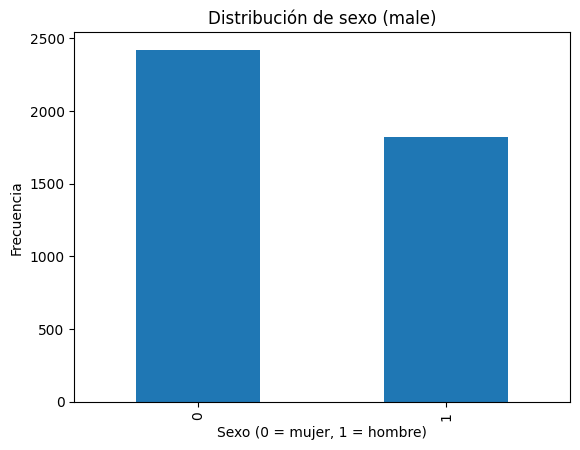

In [19]:
df['male'].value_counts().plot.bar()
plt.title("Distribución de sexo (male)")
plt.xlabel("Sexo (0 = mujer, 1 = hombre)")
plt.ylabel("Frecuencia")
plt.show()

### Análisis univariable: Sexo (male)

En este apartado analizo la variable `male`, que indica el sexo del paciente (1 = hombre, 0 = mujer).

A partir del análisis de frecuencias, observo que el dataset está compuesto aproximadamente por un 57% de mujeres y un 43% de hombres.

Esto indica que existe un ligero desbalance entre ambas categorías, aunque no es lo suficientemente elevado como para suponer un problema en el análisis.

Ambos grupos están bien representados, lo que permitirá analizar posteriormente si existen diferencias en el riesgo de enfermedad coronaria en función del sexo.

Cabe destacar que esta variable es binaria, por lo que no requiere transformaciones complejas y su interpretación resulta directa.

### Análisis univariable: Nivel educativo (education)

En este apartado analizo la variable `education`, que representa el nivel educativo del paciente.

Se trata de una variable categórica ordinal, ya que sus valores tienen un orden natural (de menor a mayor nivel educativo).

Para su análisis, calculo la frecuencia de cada categoría y la represento mediante un gráfico de barras, lo que permite observar la distribución del nivel educativo dentro del dataset.

Esta variable podría estar relacionada indirectamente con el riesgo de enfermedad coronaria, ya que el nivel educativo puede influir en hábitos de vida y acceso a recursos sanitarios.

In [20]:
# Conteo
df['education'].value_counts()

education
1.0    1720
2.0    1253
3.0     689
4.0     473
Name: count, dtype: int64

In [21]:
# Porcentaje
df['education'].value_counts(normalize=True) * 100

education
1.0    41.596131
2.0    30.302297
3.0    16.662636
4.0    11.438936
Name: proportion, dtype: float64

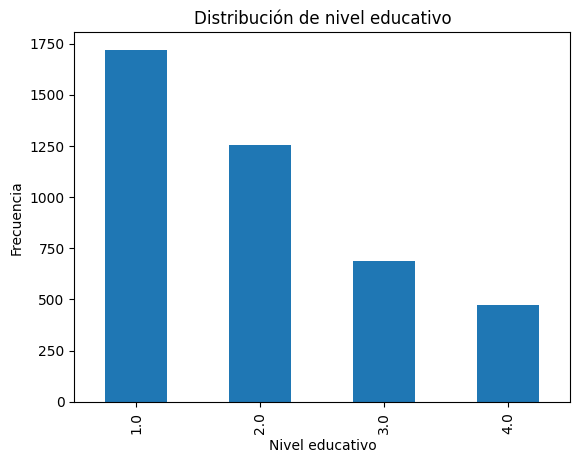

In [22]:
# Gráfico
df['education'].value_counts().sort_index().plot.bar()
plt.title("Distribución de nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Frecuencia")
plt.show()

### Análisis univariable: Nivel educativo (education)

Se trata de una variable categórica ordinal, ya que sus valores siguen un orden natural de menor a mayor nivel educativo.

A partir del análisis de frecuencias, observo que la distribución está claramente desbalanceada, concentrándose principalmente en los niveles educativos más bajos:

- El nivel 1 (sin estudios) es el más frecuente, con aproximadamente un 41.6% de los casos.
- El nivel 2 representa alrededor del 30.3%.
- Los niveles más altos (3 y 4) presentan menor representación, con un 16.6% y un 11.4% respectivamente.

Esta distribución indica que la mayor parte de los pacientes del dataset tiene un nivel educativo bajo o medio, mientras que los niveles más altos son menos frecuentes.

Cabe destacar que esta variable presenta valores nulos, los cuales serán tratados en fases posteriores del análisis para evitar introducir sesgos.

Desde el punto de vista del problema, el nivel educativo podría influir indirectamente en el riesgo de enfermedad coronaria, ya que está relacionado con factores como el estilo de vida, el acceso a la información sanitaria y los hábitos de salud.
No obstante, al tratarse de una variable ordinal, será importante tener en cuenta su naturaleza en futuros análisis, evitando tratarla como una variable categórica sin orden.

### Análisis univariable: Fumador actual (currentSmoker)

En este apartado analizo la variable `currentSmoker`, que indica si el paciente fuma actualmente.

Se trata de una variable binaria, donde 1 representa que el paciente es fumador y 0 que no lo es.

Para su análisis, calculo la frecuencia absoluta y relativa de cada categoría, y represento los resultados mediante un gráfico de barras.

El tabaquismo es uno de los principales factores de riesgo cardiovascular, por lo que esta variable resulta especialmente relevante en el contexto del problema.

In [23]:
# Conteo
df['currentSmoker'].value_counts()

currentSmoker
0    2145
1    2095
Name: count, dtype: int64

In [24]:
# Porcentaje
df['currentSmoker'].value_counts(normalize=True) * 100

currentSmoker
0    50.589623
1    49.410377
Name: proportion, dtype: float64

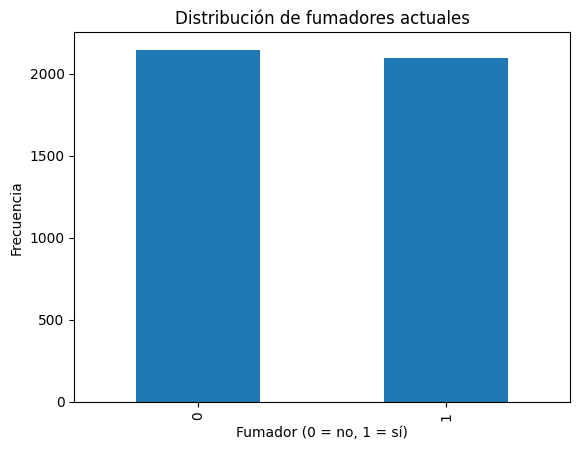

In [25]:
# Gráfico
df['currentSmoker'].value_counts().plot.bar()
plt.title("Distribución de fumadores actuales")
plt.xlabel("Fumador (0 = no, 1 = sí)")
plt.ylabel("Frecuencia")
plt.show()

### Análisis univariable: Fumador actual (currentSmoker)

Se trata de una variable binaria, donde 1 representa que el paciente es fumador y 0 que no lo es.

A partir del análisis de frecuencias, observo que el dataset está prácticamente equilibrado en esta variable, con aproximadamente un 50.6% de pacientes no fumadores y un 49.4% de fumadores.

Este equilibrio es especialmente positivo, ya que permitirá comparar ambos grupos de forma fiable en análisis posteriores sin introducir sesgos derivados del desbalance de clases.

Dado que el tabaquismo es uno de los principales factores de riesgo cardiovascular, esta variable resulta clave en el contexto del problema y se espera que tenga una influencia significativa sobre la variable objetivo.

## Ajuste en la estrategia de análisis univariable

En un primer momento, comencé realizando el análisis univariable de forma detallada variable por variable, con el objetivo de comprender en profundidad cada una de ellas.

Sin embargo, a medida que avanzaba en el análisis, observé que algunas variables del dataset comparten características similares, especialmente las variables binarias (codificadas como 0 y 1), como `male`, `currentSmoker`, `BPMeds`, `prevalentStroke`, `prevalentHyp` y `diabetes`.

Dado que estas variables representan categorías y su análisis se basa principalmente en la distribución de frecuencias, he decidido agrupar su estudio en un único bloque. Esto permite:Evitar redundancia en el análisis. Mantener una estructura más clara y organizada. Optimizar el tiempo sin perder calidad en la interpretación.

Además, aunque estas variables están codificadas como numéricas, conceptualmente se tratan como variables categóricas binarias, por lo que su análisis se realiza mediante proporciones y conteos, en lugar de distribuciones continuas.


### Análisis conjunto de variables binarias

En este apartado analizo varias variables binarias del dataset, que representan características clínicas y de estilo de vida de los pacientes.

Aunque están codificadas como valores numéricos (0 y 1), conceptualmente se tratan como variables categóricas binarias.

Para cada variable, calculo la proporción de cada categoría con el objetivo de comprender su distribución dentro del dataset.

Este análisis permite identificar posibles desbalances y evaluar la representatividad de cada grupo.

In [26]:
binary_cols = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

for col in binary_cols:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True) * 100)


male
male
0    57.075472
1    42.924528
Name: proportion, dtype: float64

currentSmoker
currentSmoker
0    50.589623
1    49.410377
Name: proportion, dtype: float64

BPMeds
BPMeds
0.0    97.038452
1.0     2.961548
Name: proportion, dtype: float64

prevalentStroke
prevalentStroke
0    99.410377
1     0.589623
Name: proportion, dtype: float64

prevalentHyp
prevalentHyp
0    68.938679
1    31.061321
Name: proportion, dtype: float64

diabetes
diabetes
0    97.429245
1     2.570755
Name: proportion, dtype: float64


### Análisis conjunto de variables binarias

En este apartado analizo varias variables binarias del dataset, que representan características clínicas y de estilo de vida de los pacientes.

A partir del análisis de proporciones, se observan diferentes comportamientos entre las variables:

Por un lado, variables como `male`, `currentSmoker` y `prevalentHyp` presentan distribuciones relativamente equilibradas. En particular:
- `male` muestra una ligera mayoría de mujeres (~57%) frente a hombres (~43%).
- `currentSmoker` está prácticamente balanceada (~50% en cada categoría).
- `prevalentHyp` presenta una proporción significativa de pacientes con hipertensión (~31%).

Por otro lado, variables como `BPMeds`, `diabetes` y `prevalentStroke` están fuertemente desbalanceadas, con una presencia muy reducida de casos positivos:
- `BPMeds` (~3%)
- `diabetes` (~2.5%)
- `prevalentStroke` (~0.6%)

Este desbalance implica que, aunque estas variables pueden ser relevantes desde un punto de vista clínico, su capacidad para aportar información en el análisis podría verse limitada debido al bajo número de observaciones en la categoría positiva.



## Análisis univariable de variables numéricas

En este apartado analizo de forma conjunta las variables numéricas del dataset.

Para cada variable, realizo:

- Un histograma, para observar la distribución de los datos.
- Un boxplot, para detectar posibles valores atípicos (outliers).
- El cálculo de la asimetría (skewness) y la curtosis, con el objetivo de comprender la forma de la distribución.

Este análisis permite identificar variables con distribuciones sesgadas, presencia de outliers o comportamientos no normales, lo cual será clave para el tratamiento posterior de los datos.

Cabe destacar que, en el cálculo de métricas estadísticas, se excluyen los valores nulos mediante `dropna()`, sin modificar el dataset original, evitando así introducir sesgos en el análisis.


----- age -----


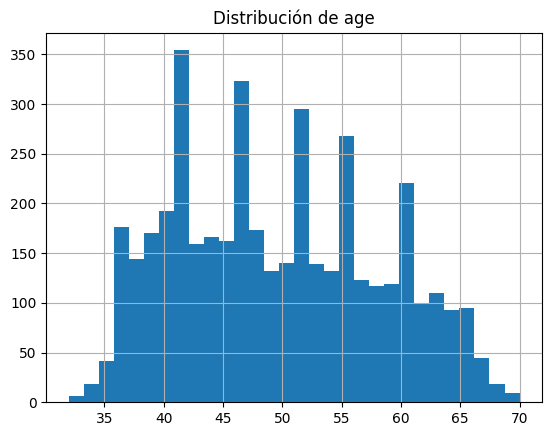

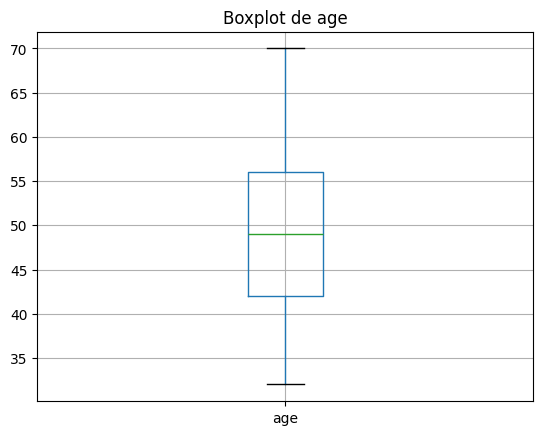

Skewness: 0.22878605874310656
Kurtosis: -0.990142826228277

----- cigsPerDay -----


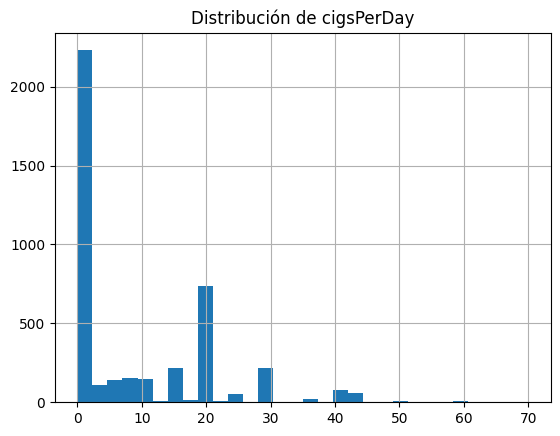

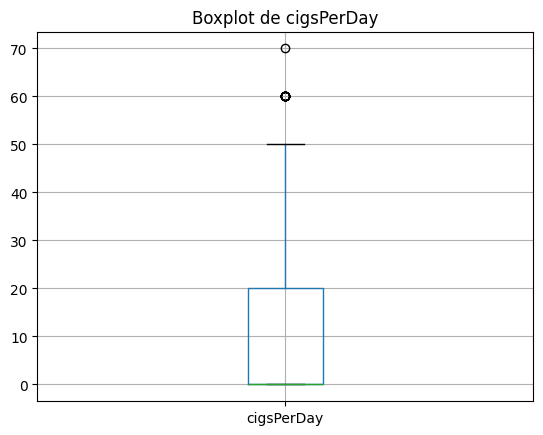

Skewness: 1.2466080997959357
Kurtosis: 1.016783707041566

----- totChol -----


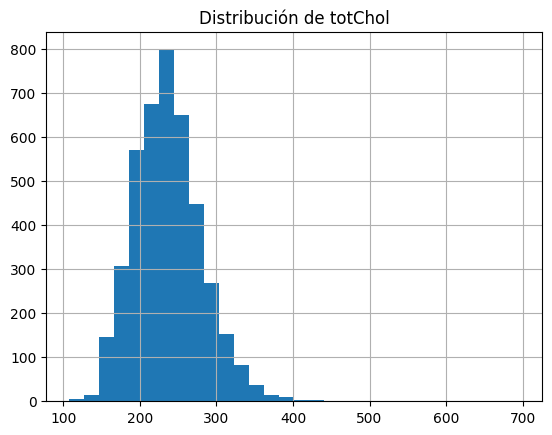

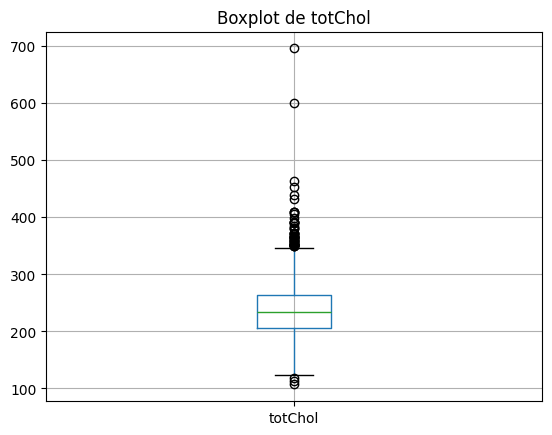

Skewness: 0.8715684033522562
Kurtosis: 4.123531157549546

----- sysBP -----


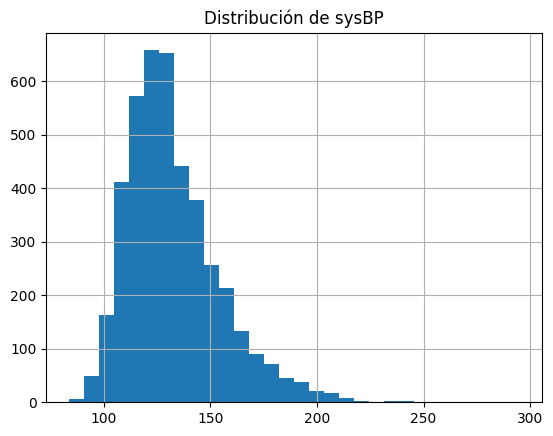

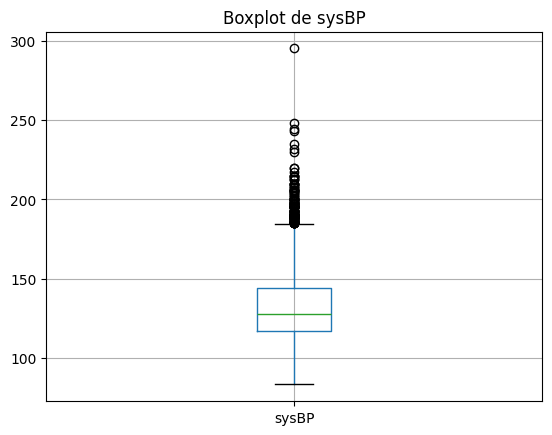

Skewness: 1.1448798241135858
Kurtosis: 2.1526664938197957

----- diaBP -----


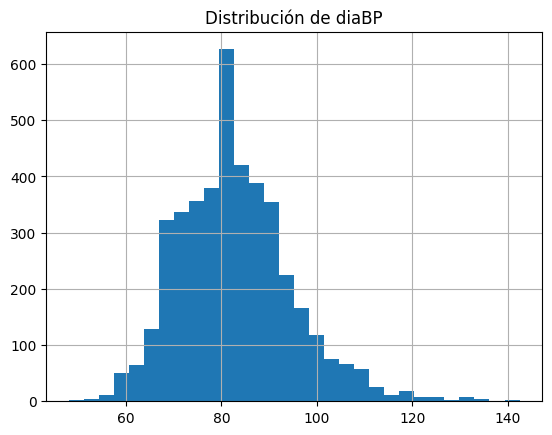

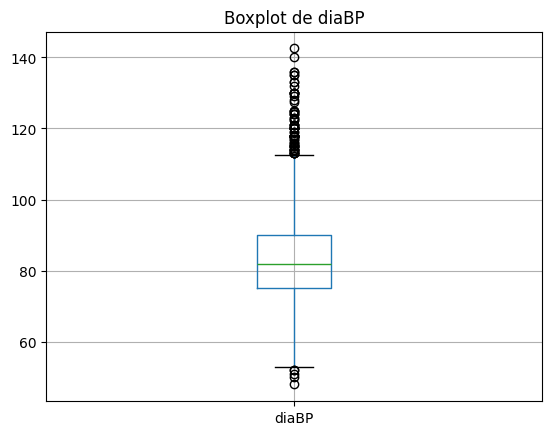

Skewness: 0.7129978589624182
Kurtosis: 1.2723961617339175

----- BMI -----


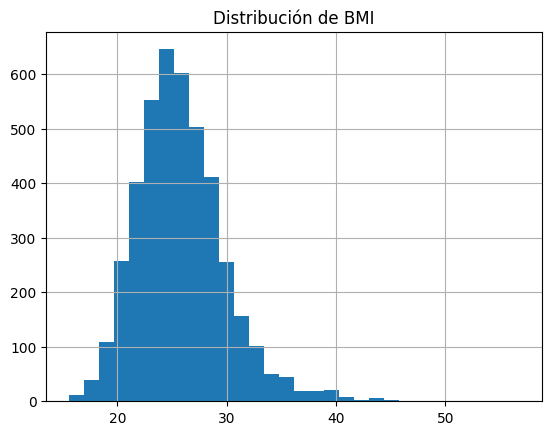

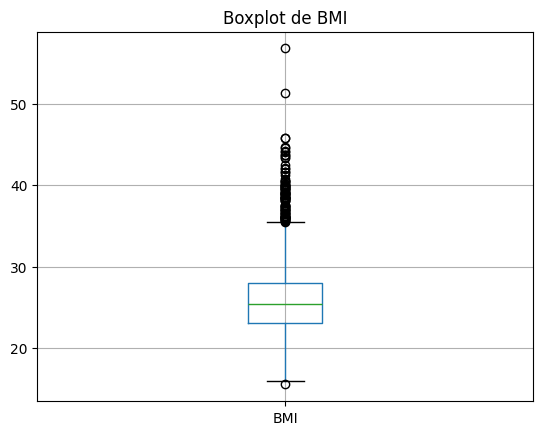

Skewness: 0.9818342296585189
Kurtosis: 2.6527417548574217

----- heartRate -----


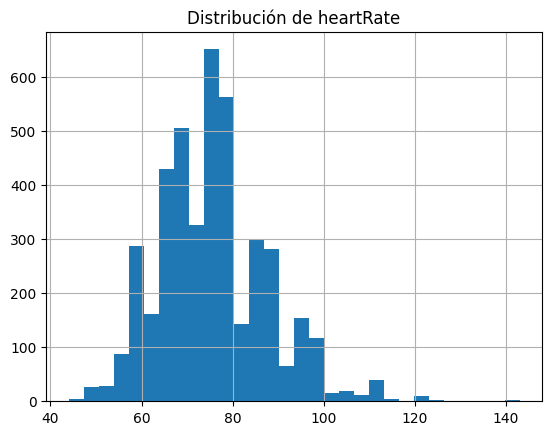

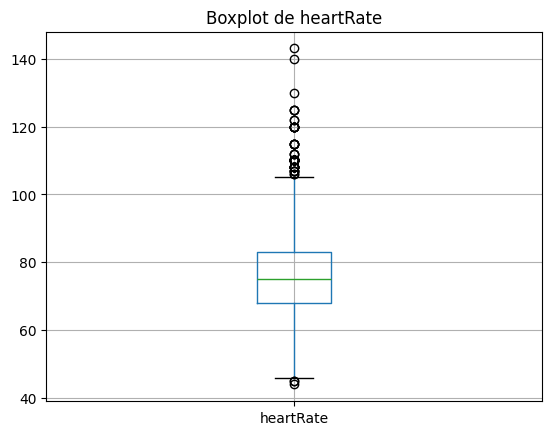

Skewness: 0.6441437781159849
Kurtosis: 0.9049106849354005

----- glucose -----


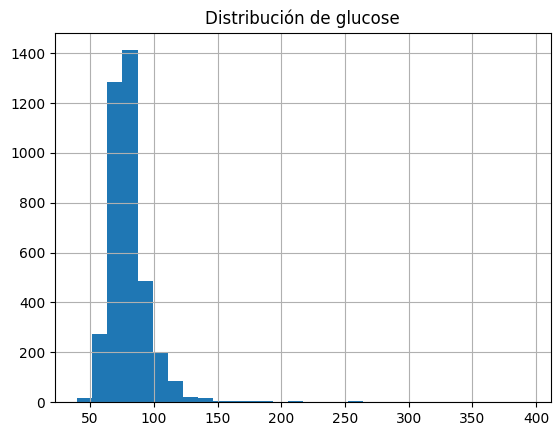

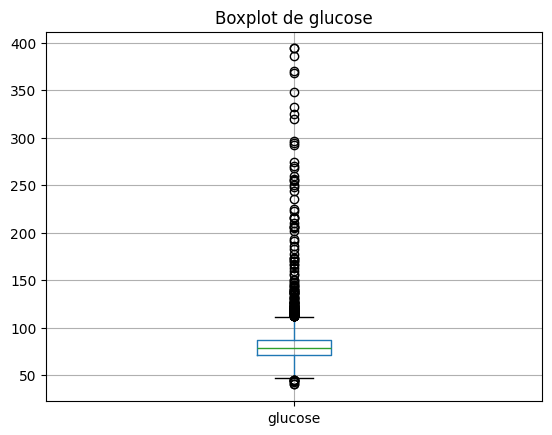

Skewness: 6.212527936475503
Kurtosis: 58.6260128366927


In [27]:
num_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
for col in num_cols:
    print(f"\n----- {col} -----")
    
    # Histograma
    df[col].hist(bins=30)
    plt.title(f"Distribución de {col}")
    plt.show()
    
    # Boxplot
    df.boxplot(column=col)
    plt.title(f"Boxplot de {col}")
    plt.show()
    
    # Estadísticos
    print("Skewness:", skew(df[col].dropna()))
    print("Kurtosis:", kurtosis(df[col].dropna()))

## Análisis univariable de variables numéricas

En este apartado analizo de forma conjunta las variables numéricas del dataset, evaluando su distribución, la presencia de valores atípicos y la forma de cada variable.

En general, se pueden identificar tres tipos de comportamientos:

Por un lado, variables como `age`, `diaBP`, `BMI` y `heartRate` presentan distribuciones relativamente equilibradas, con ligeras asimetrías y una presencia moderada de outliers. Estas variables muestran un comportamiento estable y consistente.

Por otro lado, variables como `totChol` y `sysBP` presentan una ligera asimetría positiva, con colas hacia valores altos y presencia de outliers. Este comportamiento es habitual en variables clínicas, donde ciertos pacientes pueden presentar valores elevados.

Finalmente, variables como `cigsPerDay` y `glucose` presentan una fuerte asimetría positiva. En el caso de `cigsPerDay`, esto se debe a la alta presencia de valores cero (pacientes no fumadores), mientras que en `glucose` se observa una concentración en valores bajos con numerosos valores extremos altos.

Cabe destacar que la presencia de outliers en este tipo de variables no necesariamente indica errores en los datos, sino que puede reflejar condiciones clínicas reales.

## Distribución de la variable objetivo

La variable objetivo `TenYearCHD` está desbalanceada, ya que la mayoría de pacientes no desarrolla enfermedad coronaria a 10 años.

Esto es importante porque indica que el evento positivo (`TenYearCHD = 1`) es menos frecuente, algo habitual en problemas médicos.

Este desbalance deberá tenerse en cuenta en fases posteriores si se construyen modelos predictivos.

TenYearCHD
0    3596
1     644
Name: count, dtype: int64
TenYearCHD
0    84.811321
1    15.188679
Name: proportion, dtype: float64


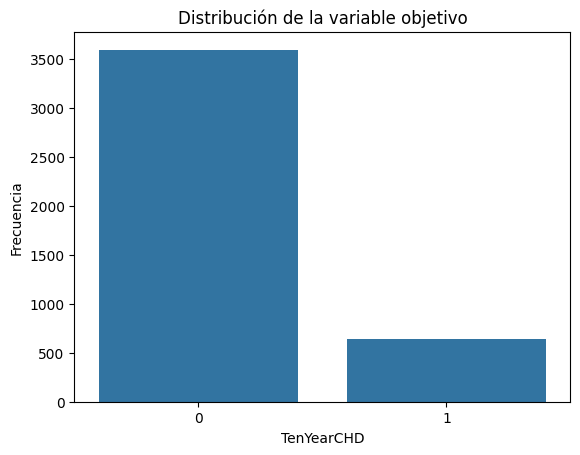

In [41]:
target_counts = df_clean['TenYearCHD'].value_counts()
target_percent = df_clean['TenYearCHD'].value_counts(normalize=True) * 100

print(target_counts)
print(target_percent)

sns.countplot(data=df_clean, x='TenYearCHD')
plt.title('Distribución de la variable objetivo')
plt.xlabel('TenYearCHD')
plt.ylabel('Frecuencia')
plt.show()

## Análisis de correlaciones

En este apartado analizo la relación entre las variables numéricas del dataset mediante una matriz de correlación.

La correlación permite identificar la relación lineal entre variables, tomando valores entre -1 y 1:
- Valores cercanos a 1 indican una fuerte correlación positiva.
- Valores cercanos a -1 indican una fuerte correlación negativa.
- Valores cercanos a 0 indican ausencia de relación lineal.

Este análisis es útil para detectar variables que aportan información similar (redundancia) y para identificar posibles relaciones relevantes entre variables.

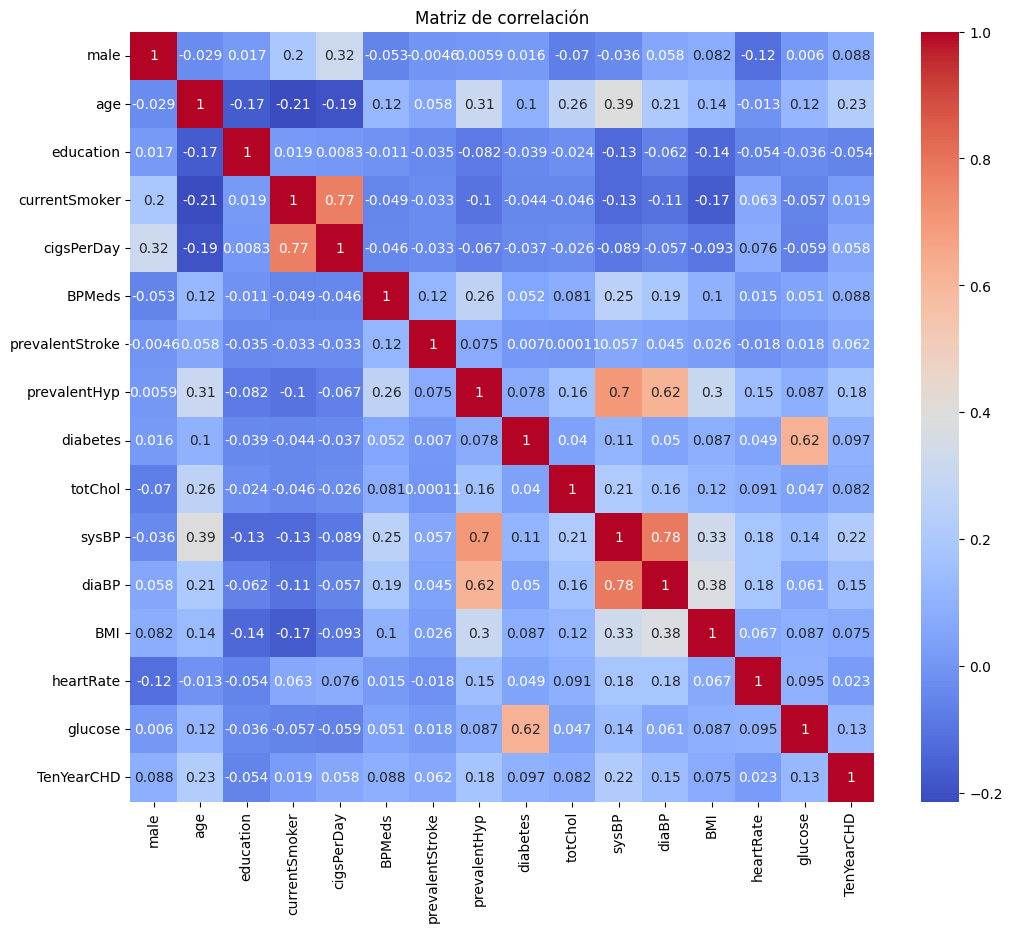

In [28]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

## Interpretación de la matriz de correlación

A partir de la matriz de correlación, se identifican varias relaciones relevantes entre las variables del dataset.

En primer lugar, destacan algunas correlaciones fuertes entre variables que miden conceptos similares:

- `sysBP` y `diaBP` presentan una correlación muy alta (~0.78), lo cual es esperable al tratarse de dos medidas de la presión arterial.
- `currentSmoker` y `cigsPerDay` también muestran una alta correlación (~0.77), ya que el número de cigarrillos depende directamente de si el paciente fuma o no.
- `prevalentHyp` presenta una fuerte correlación con `sysBP` (~0.70) y `diaBP` (~0.62), lo cual refleja la relación directa entre hipertensión y presión arterial.
- `diabetes` y `glucose` presentan una correlación elevada (~0.62), coherente con la definición clínica de la diabetes.
Por otro lado, se observan correlaciones moderadas entre variables relacionadas con el estado físico del paciente, como `BMI`, `age` y la presión arterial.
En cuanto a la variable objetivo (`TenYearCHD`), las correlaciones son relativamente bajas, siendo las más relevantes:
- `age` (~0.23)
- `sysBP` (~0.22)
- `prevalentHyp` (~0.18)
- `glucose` (~0.13)

Esto sugiere que el riesgo de enfermedad coronaria no depende de una única variable, sino de la combinación de múltiples factores.

En conjunto, este análisis permite identificar posibles redundancias entre variables y proporciona una primera aproximación a los factores que podrían influir en el riesgo cardiovascular.

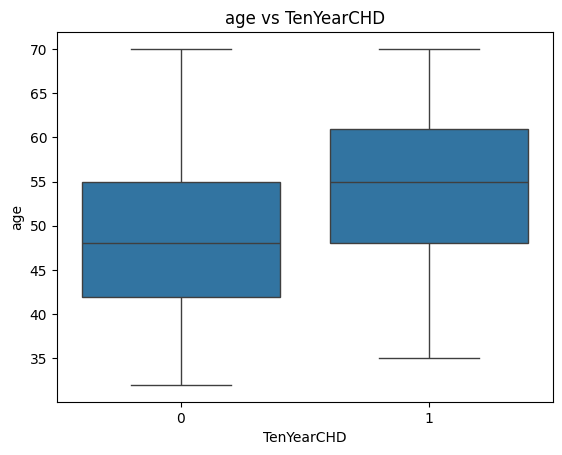

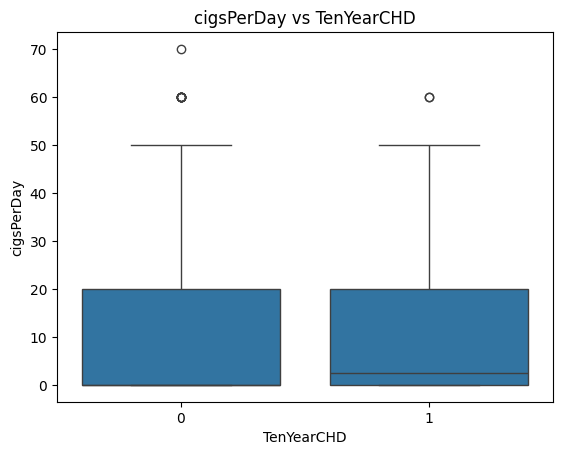

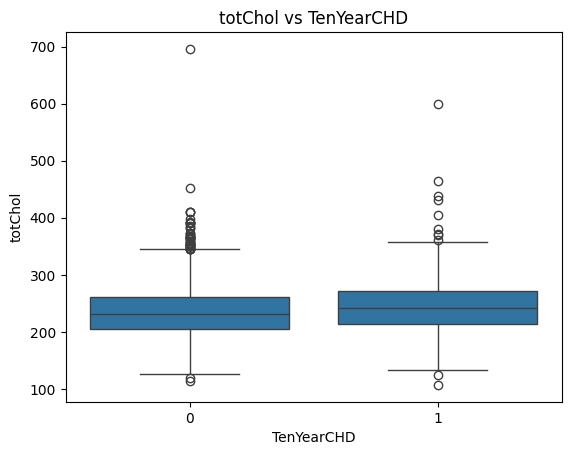

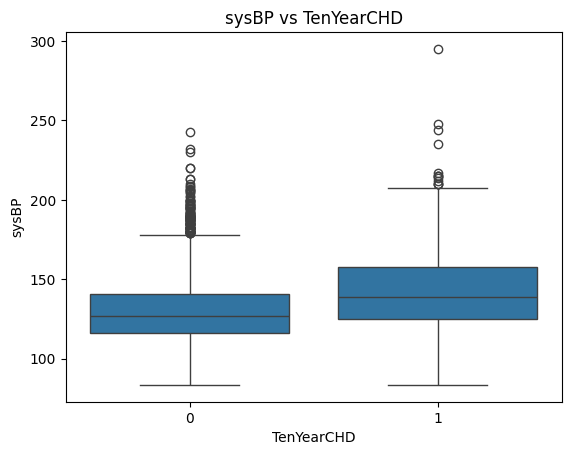

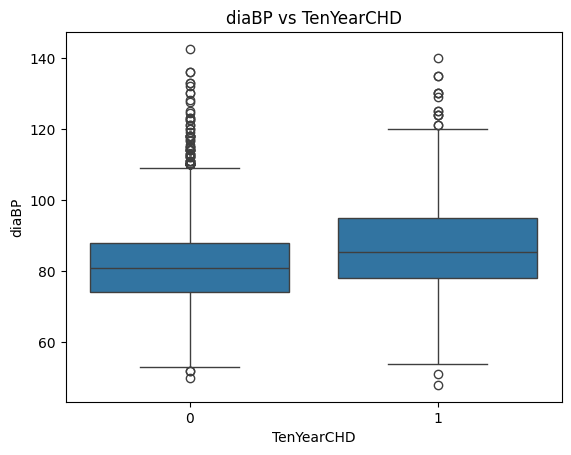

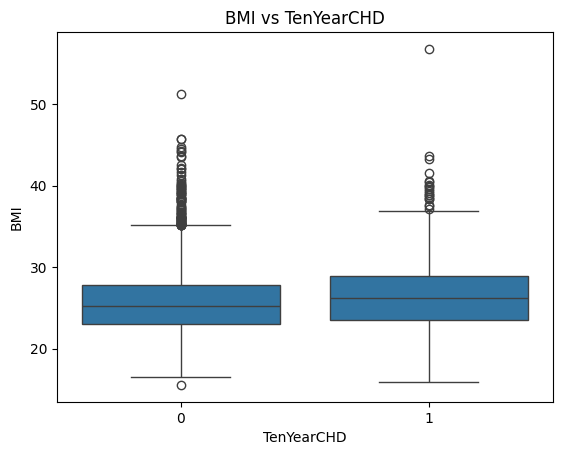

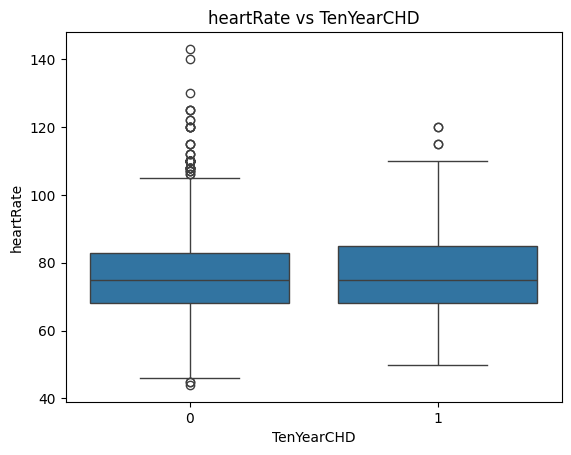

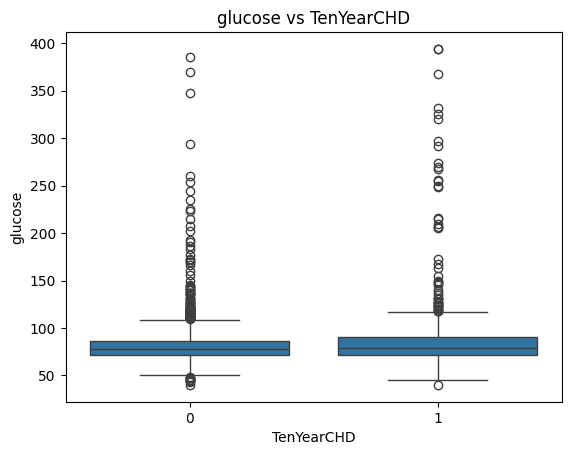

In [29]:
for col in num_cols:
    sns.boxplot(x='TenYearCHD', y=col, data=df)
    plt.title(f"{col} vs TenYearCHD")
    plt.show()

## Análisis multivariable: Relación con la variable objetivo

En este apartado analizo la relación entre las variables numéricas y la variable objetivo `TenYearCHD`, con el objetivo de identificar qué factores se asocian a un mayor riesgo de enfermedad coronaria.

A partir de los boxplots, se observan diferencias claras entre los pacientes que desarrollan la enfermedad y los que no:

Las variables que presentan mayor diferencia son:

- `age`: los pacientes con enfermedad coronaria presentan una mayor edad media, lo que confirma la hipótesis inicial sobre la influencia de la edad.
- `sysBP` y `diaBP`: ambas muestran valores significativamente más altos en pacientes con enfermedad, lo que indica una fuerte relación entre la presión arterial y el riesgo cardiovascular.

Por otro lado, variables como `BMI`, `totChol` y `glucose` presentan diferencias moderadas, lo que sugiere que también influyen en el riesgo, aunque en menor medida.

Finalmente, variables como `heartRate` o `cigsPerDay` no muestran diferencias claras entre grupos, lo que indica que su impacto podría ser más limitado o no lineal.

En conjunto, este análisis confirma que el riesgo de enfermedad coronaria está asociado principalmente a factores como la edad y la presión arterial, mientras que otros factores tienen un impacto más moderado.

Estos resultados permiten contrastar las hipótesis iniciales planteadas al comienzo del análisis.

# Nulos y Atípicos

In [30]:
df_clean = df.copy()

## Creación del dataset limpio

A partir de este punto creo una copia del dataset original llamada `df_clean`.

De esta forma mantengo intacto el dataset bruto (`df`) y realizo las decisiones de limpieza sobre una copia. Esto permite conservar los datos originales y comparar los cambios realizados durante el análisis.

In [31]:
# Imputación de variables numéricas con mediana
for col in ['glucose', 'totChol', 'cigsPerDay', 'BMI', 'heartRate']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Imputación de variables categóricas/binarias con moda
for col in ['education', 'BPMeds']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Comprobación final de nulos
df_clean.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

## Análisis de cardinalidad

En este apartado analizo el número de valores únicos de cada variable.

Este análisis permite identificar variables con baja cardinalidad, como las variables binarias o categóricas, y variables con mayor variabilidad, como las variables numéricas.

En este dataset, la mayoría de variables presentan una cardinalidad baja o moderada, lo cual facilita su interpretación y análisis.

No se observan variables con una cardinalidad extremadamente alta que requieran transformaciones específicas en esta fase.

In [32]:
df_clean.nunique().sort_values(ascending=False)

BMI                1364
totChol             248
sysBP               234
diaBP               146
glucose             143
heartRate            73
age                  39
cigsPerDay           33
education             4
male                  2
currentSmoker         2
BPMeds                2
prevalentStroke       2
prevalentHyp          2
diabetes              2
TenYearCHD            2
dtype: int64

## Análisis de valores atípicos

A partir del análisis de percentiles y los boxplots realizados anteriormente, se identifican valores atípicos en varias variables numéricas.

Sin embargo, en este contexto estos valores pueden representar casos clínicos reales, como pacientes con niveles elevados de glucosa, colesterol o presión arterial.

Por este motivo, no se eliminan los outliers de forma automática, ya que podrían contener información relevante para el análisis del riesgo cardiovascular.

En futuras fases, si fuera necesario, se podrían aplicar técnicas como transformaciones o métodos robustos, pero en este análisis exploratorio se prioriza mantener la información original.

In [33]:
df_clean.describe(percentiles=[.25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
male,4240.0,0.429245,0.495027,0.00,0.0000,0.0,1.0000,1.000,1.0000,1.0000,1.0
age,4240.0,49.580189,8.572942,32.00,42.0000,49.0,56.0000,62.000,64.0000,67.0000,70.0
education,4240.0,1.955189,1.018522,1.00,1.0000,2.0,3.0000,4.000,4.0000,4.0000,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.0000,0.0,1.0000,1.000,1.0000,1.0000,1.0
cigsPerDay,4240.0,8.944340,11.904777,0.00,0.0000,0.0,20.0000,25.000,30.0000,43.0000,70.0
BPMeds,4240.0,0.029245,0.168513,0.00,0.0000,0.0,0.0000,0.000,0.0000,1.0000,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.0000,0.0,0.0000,0.000,0.0000,0.0000,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.0000,0.0,1.0000,1.000,1.0000,1.0000,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.0000,0.0,0.0000,0.000,0.0000,1.0000,1.0
totChol,4240.0,236.667689,44.328480,107.00,206.0000,234.0,262.0000,292.000,312.0000,353.6100,696.0


## Experimento de winsorización

Como parte del análisis de valores atípicos, realizo un experimento de winsorización sobre algunas variables numéricas.

La winsorización consiste en limitar los valores extremos superiores a un percentil determinado, en este caso el percentil 99. El objetivo es comprobar cómo se comportan las distribuciones si se reduce el impacto visual de los valores extremos.

Es importante destacar que este proceso se realiza sobre una copia del dataset (`df_windsorized`) y no sustituye al dataset limpio principal (`df_clean`).

En este caso, al tratarse de variables clínicas, los valores extremos pueden representar pacientes reales con mayor riesgo cardiovascular. Por tanto, no se eliminan ni se modifican definitivamente en el dataset principal.

In [39]:
def windsorize_upper(df, columns, upper_percentile=0.99):
    """
    Limita los valores superiores de cada columna al percentil indicado.
    No modifica el dataset original, solo devuelve una copia transformada.
    """
    df_copy = df.copy()
    
    for col in columns:
        upper_limit = df_copy[col].quantile(upper_percentile)
        df_copy[col] = np.where(df_copy[col] > upper_limit, upper_limit, df_copy[col])
        
    return df_copy


cols_to_windsorize = ['cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

df_windsorized = windsorize_upper(df_clean, cols_to_windsorize, upper_percentile=0.99)

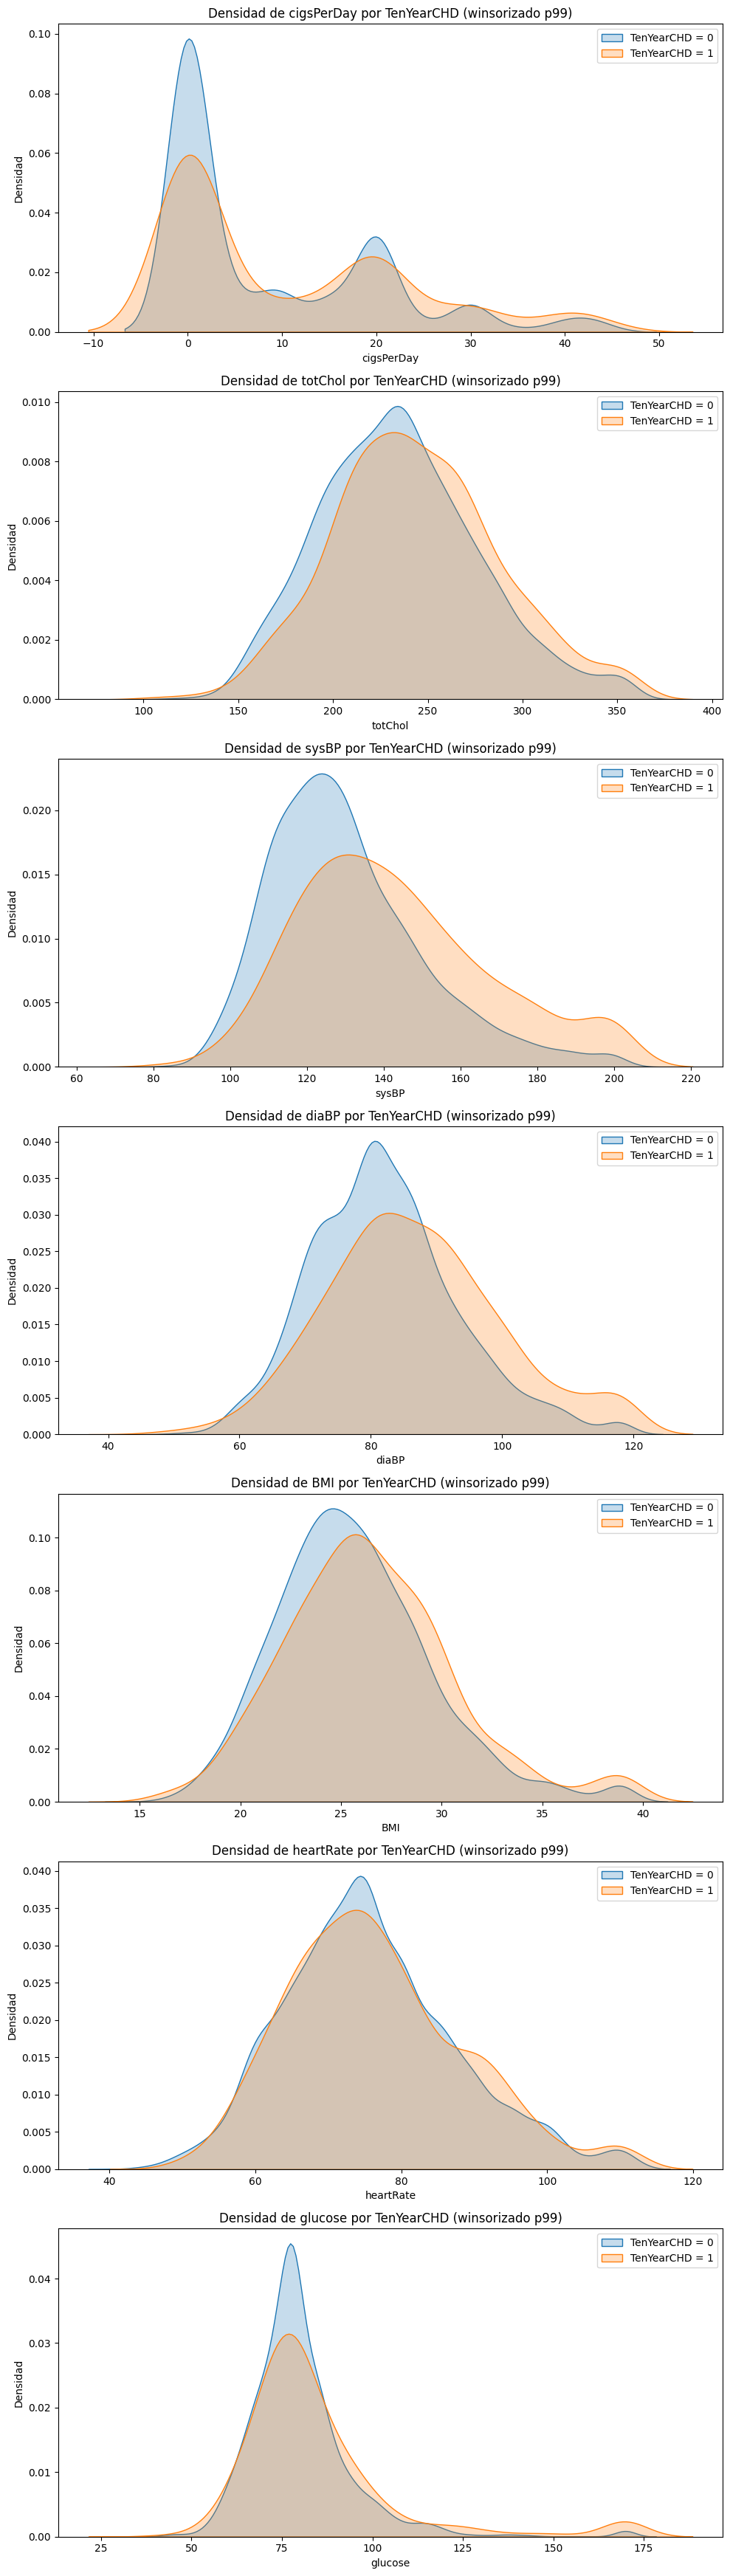

In [40]:
target = 'TenYearCHD'

fig, axs = plt.subplots(
    nrows=len(cols_to_windsorize),
    ncols=1,
    figsize=(10, 5 * len(cols_to_windsorize))
)

for i, col in enumerate(cols_to_windsorize):
    sns.kdeplot(
        data=df_windsorized[df_windsorized[target] == 0],
        x=col,
        ax=axs[i],
        label=f'{target} = 0',
        fill=True
    )
    
    sns.kdeplot(
        data=df_windsorized[df_windsorized[target] == 1],
        x=col,
        ax=axs[i],
        label=f'{target} = 1',
        fill=True
    )
    
    axs[i].set_title(f'Densidad de {col} por {target} (winsorizado p99)')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Densidad')
    axs[i].legend()

plt.tight_layout()
plt.show()

## Análisis bivariado: variables numéricas frente al target

En este apartado analizo la distribución de las variables numéricas según la variable objetivo `TenYearCHD`.

Para ello utilizo gráficos de densidad (KDE), que permiten comparar visualmente si los pacientes que desarrollaron enfermedad coronaria presentan distribuciones diferentes respecto a los que no la desarrollaron.

Este análisis ayuda a identificar variables que podrían estar asociadas al riesgo cardiovascular.

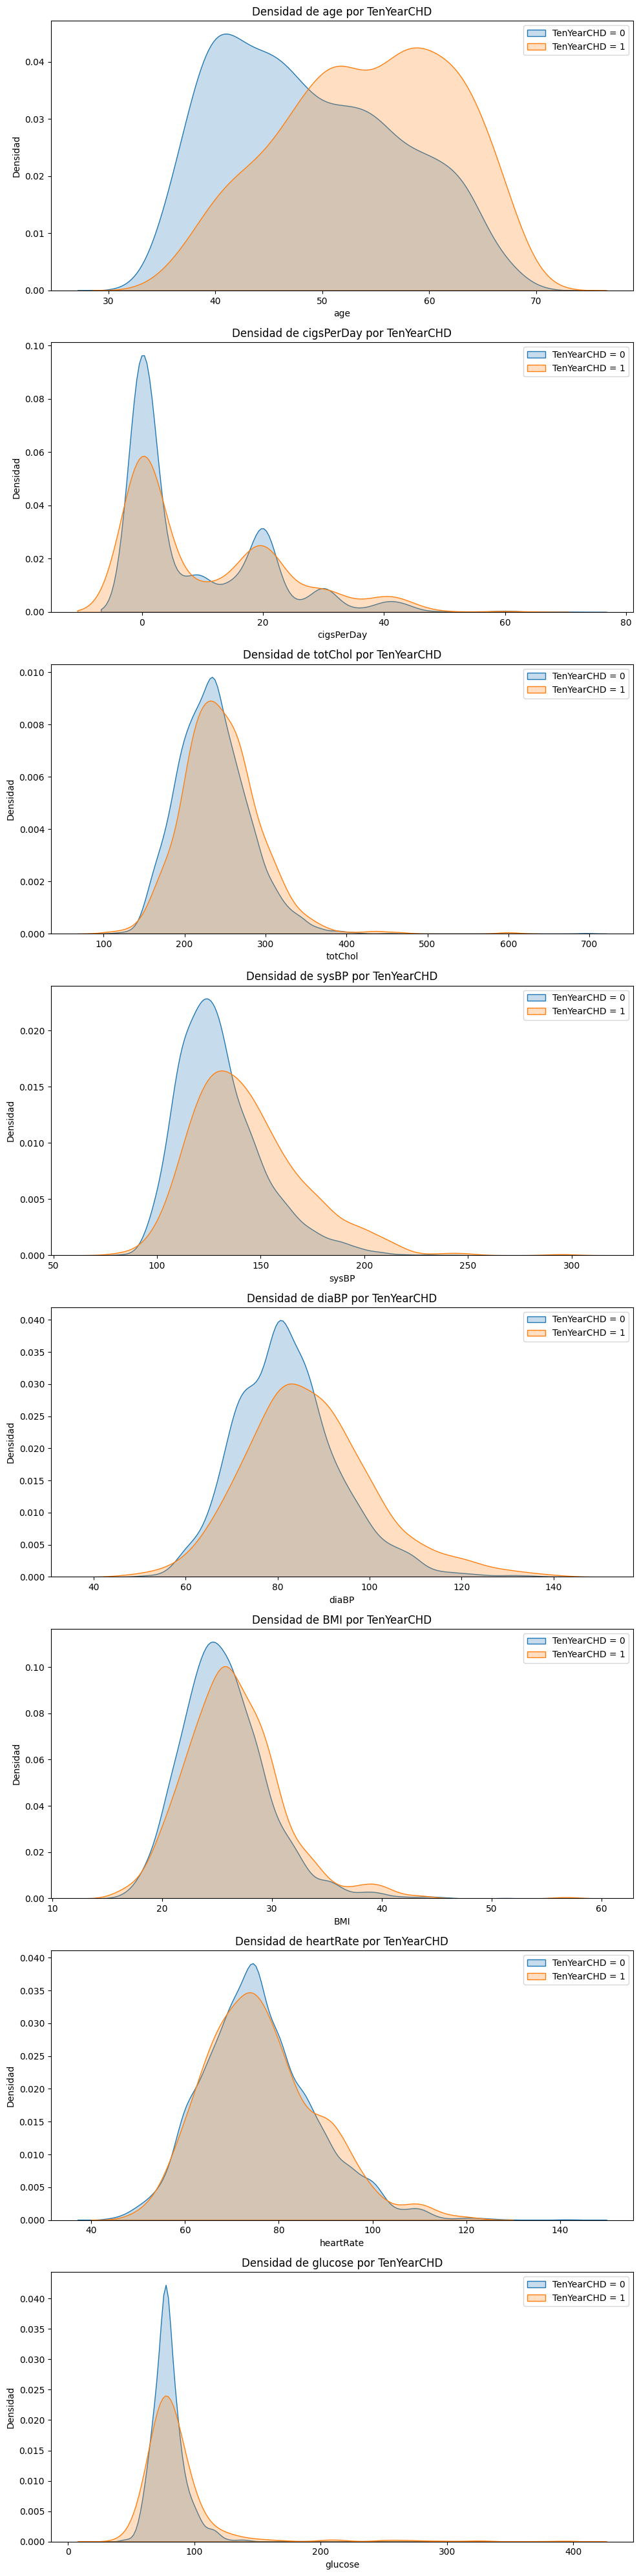

In [38]:
target = 'TenYearCHD'

fig, axs = plt.subplots(nrows=len(numeric_cols), ncols=1, figsize=(10, 5 * len(numeric_cols)))

# Graficar cada columna numérica contra el target
for i, col in enumerate(numeric_cols):
    sns.kdeplot(
        data=df_clean[df_clean[target] == df_clean[target].unique()[0]],
        x=col,
        ax=axs[i],
        label=f'{target} = {df_clean[target].unique()[0]}',
        fill=True
    )
    
    sns.kdeplot(
        data=df_clean[df_clean[target] == df_clean[target].unique()[1]],
        x=col,
        ax=axs[i],
        label=f'{target} = {df_clean[target].unique()[1]}',
        fill=True
    )
    
    axs[i].set_title(f'Densidad de {col} por {target}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Densidad')
    axs[i].legend()

plt.tight_layout()
plt.show()

### Relación entre tabaquismo y enfermedad coronaria

Analizo la relación entre la variable `currentSmoker` y la variable objetivo.

Aunque visualmente puede parecer que existe cierta diferencia entre fumadores y no fumadores, el test Chi-cuadrado realizado anteriormente indica que esta relación no es estadísticamente significativa.

Sin embargo, al analizar la variable `cigsPerDay`, que mide la cantidad de cigarrillos consumidos, sí se observa una diferencia significativa según el test ANOVA.

Por tanto, concluyo que el tabaquismo sí tiene impacto, pero está mejor representado por la intensidad del consumo que por la variable binaria de si el individuo fuma o no.

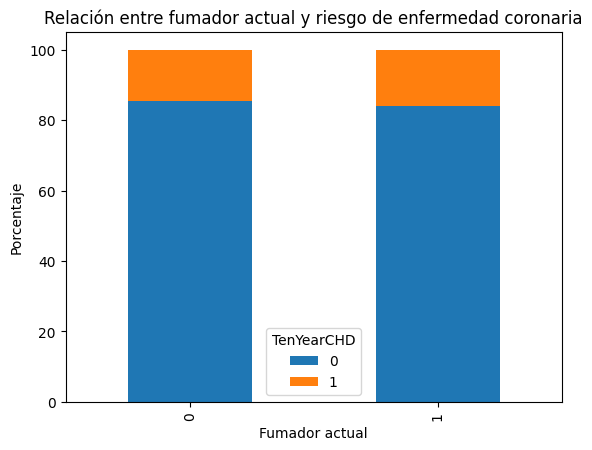

In [42]:
# Relación entre fumador y enfermedad coronaria
smoker_target = pd.crosstab(
    df_clean['currentSmoker'],
    df_clean['TenYearCHD'],
    normalize='index'
) * 100

smoker_target.plot(kind='bar', stacked=True)

plt.title('Relación entre fumador actual y riesgo de enfermedad coronaria')
plt.xlabel('Fumador actual')
plt.ylabel('Porcentaje')
plt.legend(title='TenYearCHD')
plt.show()

### Relación entre tabaquismo y enfermedad coronaria

En este gráfico se observa la distribución de la variable objetivo en función de si el paciente es fumador o no.

A simple vista, las proporciones de enfermedad coronaria son muy similares entre fumadores y no fumadores, con una ligera mayor incidencia en los fumadores.

Sin embargo, la diferencia no es lo suficientemente marcada como para considerar esta variable como altamente discriminante por sí sola.

Esto coincide con el test Chi-cuadrado, donde no se observa una relación estadísticamente significativa fuerte.

Por tanto, concluyo que la variable `currentSmoker` tiene un impacto limitado de forma individual, aunque puede aportar valor en combinación con otras variables como `cigsPerDay`.

Es interesante destacar que, aunque la variable binaria de tabaquismo no muestra una gran diferencia, la variable `cigsPerDay` sí presenta diferencias significativas, lo que sugiere que la intensidad del consumo es más relevante que el hecho de fumar o no.

## Test ANOVA

Para complementar el análisis visual, aplico un test ANOVA entre las variables numéricas y la variable objetivo `TenYearCHD`.

Este test permite determinar si existen diferencias estadísticamente significativas entre los grupos.

Un p-valor inferior a 0.05 indica que la variable presenta diferencias significativas entre pacientes con y sin enfermedad coronaria.

In [35]:
numeric_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

anova_results = []

for col in numeric_cols:
    group0 = df_clean[df_clean['TenYearCHD'] == 0][col]
    group1 = df_clean[df_clean['TenYearCHD'] == 1][col]
    stat, p = f_oneway(group0, group1)
    anova_results.append([col, stat, p])

anova_df = pd.DataFrame(anova_results, columns=['variable', 'F_statistic', 'p_value'])
anova_df.sort_values('p_value')

,variable,F_statistic,p_value
0,age,226.853168,5.573313e-50
3,sysBP,208.158627,4.217070e-46
4,diaBP,91.160759,2.170620e-21
7,glucose,63.307530,2.251188e-15
2,totChol,28.512751,9.795875e-08
5,BMI,23.542049,1.266045e-06
1,cigsPerDay,14.668063,1.300534e-04
6,heartRate,2.214058,1.368330e-01


## Resultados del test ANOVA

A partir del test ANOVA aplicado sobre las variables numéricas, se observan diferencias estadísticamente significativas entre los pacientes con y sin enfermedad coronaria en la mayoría de variables analizadas.

Las variables más relevantes son:

- `age` y `sysBP`, que presentan los valores más altos del estadístico F y p-valores extremadamente bajos, indicando una fuerte relación con el riesgo de enfermedad coronaria.
- `diaBP` y `glucose`, que también muestran una relación significativa con la variable objetivo.

Por otro lado, variables como `totChol`, `BMI` y `cigsPerDay` presentan diferencias significativas, aunque con menor intensidad.

Finalmente, la variable `heartRate` no presenta diferencias estadísticamente significativas (p > 0.05), lo que sugiere que su impacto en el riesgo de enfermedad coronaria es limitado.

Estos resultados confirman las observaciones realizadas previamente en el análisis visual, reforzando la importancia de factores como la edad y la presión arterial en el desarrollo de enfermedad coronaria.

## Test Chi-cuadrado

Para analizar la relación entre variables categóricas y la variable objetivo, aplico el test Chi-cuadrado.

Este test permite comprobar si existe asociación entre las variables.

Un p-valor inferior a 0.05 indica que existe relación significativa entre la variable y el riesgo de enfermedad coronaria.

In [37]:
cat_cols = ['male', 'education', 'currentSmoker', 'BPMeds', 
            'prevalentStroke', 'prevalentHyp', 'diabetes']

chi_results = []

for col in cat_cols:
    table = pd.crosstab(df_clean[col], df_clean['TenYearCHD'])
    chi2, p, dof, expected = chi2_contingency(table)
    chi_results.append([col, chi2, p])

chi_df = pd.DataFrame(chi_results, columns=['variable', 'chi2', 'p_value'])
chi_df.sort_values('p_value')

,variable,chi2,p_value
5,prevalentHyp,132.456286,1.188961e-30
6,diabetes,38.482338,5.525144e-10
0,male,32.618335,1.121518e-08
3,BPMeds,30.272895,3.753344e-08
1,education,31.051850,8.289453e-07
4,prevalentStroke,14.033657,1.795676e-04
2,currentSmoker,1.497204,2.211021e-01


## Resultados del test Chi-cuadrado
Las variables que presentan una asociación estadísticamente significativa son:

- `prevalentHyp`, que muestra la relación más fuerte, indicando que la hipertensión está claramente asociada con el riesgo de enfermedad coronaria.
- `diabetes`, que también presenta una relación significativa, coherente con su impacto en la salud cardiovascular.
- `male`, lo que sugiere diferencias en el riesgo según el sexo.
- `BPMeds`, relacionada con el tratamiento de la presión arterial.
- `education`, que podría influir indirectamente a través del estilo de vida y acceso a información sanitaria.
- `prevalentStroke`, que también muestra una asociación significativa.

Por otro lado, la variable `currentSmoker` no presenta una relación estadísticamente significativa (p > 0.05), lo que sugiere que, de forma aislada, no está directamente asociada con el desarrollo de enfermedad coronaria a 10 años en este dataset.

Este resultado indica que el impacto del tabaquismo podría depender de otros factores o manifestarse de forma no lineal.

# Análisis multivariante

En este apartado resumo las relaciones entre variables analizadas anteriormente.

Las variables numéricas muestran correlación moderada con el target, destacando `age`, `sysBP` y `glucose`.

En variables categóricas, el test Chi-cuadrado confirma la relevancia de `prevalentHyp`, `diabetes` y `BPMeds`.

Además, mediante Cramér’s V se observa que existen relaciones entre variables categóricas, aunque ninguna sustituye completamente a otra.

Finalmente, la información mutua refuerza la importancia de variables como `age`, `sysBP` y `cigsPerDay`.

# Contraste de hipótesis

Al inicio del análisis se planteó que variables como edad, presión arterial, colesterol, glucosa y tabaquismo podían influir en el riesgo de enfermedad coronaria.

Tras el EDA, puedo concluir que:

- La edad confirma claramente la hipótesis, siendo una de las variables más influyentes.
- La presión arterial (`sysBP` y `diaBP`) también confirma la hipótesis con una fuerte relación.
- La glucosa y la diabetes presentan una relación significativa con el riesgo.
- El colesterol tiene impacto, aunque menor que otras variables.
- El tabaquismo se confirma parcialmente: `currentSmoker` no es muy fuerte, pero `cigsPerDay` sí.

Por otro lado, variables como `heartRate` no parecen tener impacto relevante.

# Conclusiones finales

Tras realizar el análisis exploratorio de datos, se observa que el dataset presenta un cierto desbalanceo en la variable objetivo, con mayor proporción de pacientes sin enfermedad coronaria.

Las variables más relevantes para explicar el riesgo de enfermedad coronaria son:

- Edad (`age`)
- Presión arterial (`sysBP`, `diaBP`)
- Glucosa (`glucose`)
- Hipertensión (`prevalentHyp`)
- Diabetes (`diabetes`)
- Colesterol (`totChol`)
- Consumo de tabaco (`cigsPerDay`)

Se concluye que el riesgo cardiovascular depende principalmente de factores clínicos, aunque también influyen factores de estilo de vida como el tabaquismo.

Además, no existe una única variable determinante, sino que el riesgo se explica por la combinación de múltiples variables.